# Quantum Walk Search Scaling

This benchmark notebook sweeps small complete-graph quantum walk search
instances and polynomial degrees. It compares exact dense search dynamics with
the QSVT-style polynomial phase approximation returned by
`quantum_walk_search_workflow`.

The output is an algorithm-comparison benchmark, not a wall-clock runtime
benchmark. It writes a machine-readable JSON report, a compact CSV summary, and
embedded diagnostic plots.

## Benchmark Scope, QSVT Proxy Strategy, and Interpretation

**Benchmark scope.** The sweep uses complete graphs with one marked vertex and
default hopping rate `gamma = 1 / n`. Exact dense spectral evolution supplies
the reference marked-vertex probability.

**QSVT proxy strategy.** For each graph size and polynomial degree, the workflow
fits cosine and sine phase polynomials for the best sampled search time. The
resource proxy records degree, phase-count proxy, and signal-call proxy.

**Interpretation.** These small dense runs validate approximation behavior and
claim boundaries. They do not include graph or marking oracle construction,
state preparation, phase synthesis, sampling, or hardware execution costs.

## Variable definitions

- `n_vertices`: number of vertices in the complete graph.
- `degree`: polynomial degree used for the best-time phase approximation.
- `adjacency`: complete-graph adjacency matrix.
- `result`: `QuantumWalkSearchWorkflowResult` for one sweep point.
- `rows`: compact summary rows written to CSV.
- `reports`: JSON-safe workflow reports for all sweep points.
- `ARTIFACT_DIR`, `TABLE_DIR`: output directories for JSON and CSV artifacts.

In [1]:
import csv

import matplotlib.pyplot as plt
import numpy as np

from qsvt import quantum_walk_search_workflow, report_to_jsonable, save_report
from qsvt.notebook import benchmark_output_dirs, display_table


ROOT, ARTIFACT_DIR, TABLE_DIR = benchmark_output_dirs()


def complete_graph_adjacency(n_vertices):
    return np.ones((n_vertices, n_vertices), dtype=float) - np.eye(n_vertices)



def write_rows_csv(rows, path):
    fieldnames = [
        "n_vertices",
        "degree",
        "best_time",
        "best_probability",
        "polynomial_marked_probability",
        "probability_error",
        "state_relative_error",
        "operator_relative_error",
        "qsp_phase_count",
        "signal_call_proxy",
    ]
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    return path

## Graph Size And Degree Sweep

The sweep keeps the time grid fixed and varies both graph size and polynomial
degree. This separates exact search success from approximation quality.

In [2]:
sweep_specs = [
    (4, 8),
    (4, 14),
    (8, 8),
    (8, 14),
    (16, 10),
    (16, 18),
]

reports = []
rows = []
for n_vertices, degree in sweep_specs:
    adjacency = complete_graph_adjacency(n_vertices)
    result = quantum_walk_search_workflow(
        adjacency,
        marked_vertex=0,
        degree=degree,
        num_points=801,
        num_time_points=121,
    )
    report = report_to_jsonable(result.as_report())
    proxy = report["resource_proxy"]
    reports.append(report)
    rows.append(
        {
            "n_vertices": n_vertices,
            "degree": degree,
            "best_time": result.best_time,
            "best_probability": result.best_probability,
            "polynomial_marked_probability": result.polynomial_marked_probability,
            "probability_error": result.probability_error,
            "state_relative_error": result.state_relative_error,
            "operator_relative_error": result.operator_relative_error,
            "qsp_phase_count": proxy["qsp_phase_count"],
            "signal_call_proxy": proxy["signal_call_proxy"],
        }
    )

scaling_report = {
    "mode": "quantum-walk-search-scaling-benchmark",
    "implementation_kind": "dense-spectral-polynomial-workflow-sweep",
    "truth_contract": {
        "truth_status": "algorithm_comparison_benchmark",
        "is_quantum_runtime_benchmark": False,
        "is_end_to_end_quantum_algorithm": False,
        "implemented_components": [
            "complete_graph_dense_adjacency",
            "exact_dense_spectral_search_dynamics",
            "best_time_grid_search",
            "polynomial_phase_approximation",
            "resource_proxy_summary",
        ],
        "omitted_quantum_costs": reports[0]["resource_proxy"]["omitted_layers"],
    },
    "sweep_parameters": {
        "graph_family": "complete_graph",
        "marked_vertex": 0,
        "num_time_points": 121,
        "num_fit_points": 801,
        "sweep_specs": [list(spec) for spec in sweep_specs],
    },
    "rows": rows,
    "reports": reports,
}

json_path = save_report(
    scaling_report,
    ARTIFACT_DIR / "quantum_walk_search_scaling.json",
)
csv_path = write_rows_csv(
    rows,
    TABLE_DIR / "quantum_walk_search_scaling_summary.csv",
)

display_table(
    "Quantum walk search scaling",
    rows,
    [
        ("Vertices", lambda row: row["n_vertices"]),
        ("Degree", lambda row: row["degree"]),
        ("Best probability", lambda row: row["best_probability"]),
        ("Polynomial probability", lambda row: row["polynomial_marked_probability"]),
        ("Probability error", lambda row: row["probability_error"]),
        ("State error", lambda row: row["state_relative_error"]),
        ("Signal calls", lambda row: row["signal_call_proxy"]),
    ],
)
print("JSON:", json_path)
print("CSV:", csv_path)

Quantum walk search scaling
---------------------------
Vertices : 4 | 4 | 8 | 8 | 16 | 16
Degree : 8 | 14 | 8 | 14 | 10 | 18
Best probability : 1 | 1 | 1 | 1 | 1 | 1
Polynomial probability : 0.9999 | 1 | 0.9998 | 1 | 0.9999 | 1
Probability error : 6.28e-05 | 6.18e-11 | 1.89e-04 | 5.21e-10 | 1.35e-04 | 1.19e-11
State error : 3.96e-05 | 3.55e-11 | 2.05e-04 | 1.02e-09 | 9.39e-05 | 1.07e-11
Signal calls : 8 | 14 | 8 | 14 | 10 | 18
JSON: /workspaces/Quantum_Singular_Value_Transformation/results/benchmarks/quantum_walk_search_scaling.json
CSV: /workspaces/Quantum_Singular_Value_Transformation/results/tables/quantum_walk_search_scaling_summary.csv


## Visual Diagnostics

The plots show exact search success and polynomial approximation error across
the finite sweep. The signal-call panel is a QSVT proxy, not a runtime.

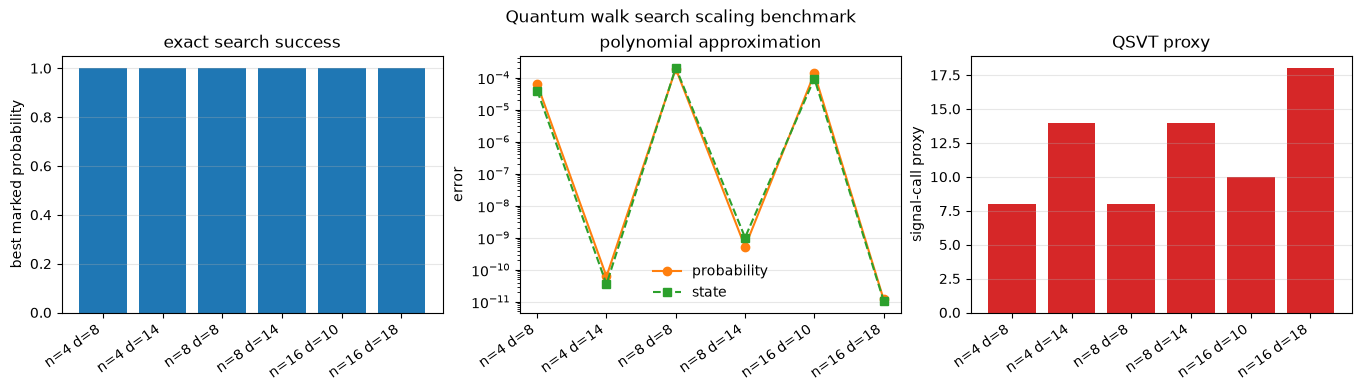

In [3]:
labels = [f"n={row['n_vertices']} d={row['degree']}" for row in rows]
x = np.arange(len(rows))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
axes[0].bar(x, [row["best_probability"] for row in rows], color="tab:blue")
axes[0].set_xticks(x, labels, rotation=35, ha="right")
axes[0].set_ylim(0.0, 1.05)
axes[0].set_ylabel("best marked probability")
axes[0].set_title("exact search success")
axes[0].grid(axis="y", alpha=0.3)

axes[1].semilogy(
    x,
    [max(row["probability_error"], 1e-16) for row in rows],
    "o-",
    color="tab:orange",
    label="probability",
)
axes[1].semilogy(
    x,
    [max(row["state_relative_error"], 1e-16) for row in rows],
    "s--",
    color="tab:green",
    label="state",
)
axes[1].set_xticks(x, labels, rotation=35, ha="right")
axes[1].set_ylabel("error")
axes[1].set_title("polynomial approximation")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(frameon=False)

axes[2].bar(x, [row["signal_call_proxy"] for row in rows], color="tab:red")
axes[2].set_xticks(x, labels, rotation=35, ha="right")
axes[2].set_ylabel("signal-call proxy")
axes[2].set_title("QSVT proxy")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Quantum walk search scaling benchmark")
plt.show()

## Quantum-Advantage Interpretation

The exact dense reference confirms that the complete-graph search dynamics can
amplify the marked state strongly on these small instances. The polynomial
error columns show how much degree is needed to reproduce the best-time phase
response.

A scalable advantage claim would still require favorable graph and marking
oracles, efficient state preparation, phase synthesis, and a readout strategy
that does not reconstruct the whole state.